<a href="https://colab.research.google.com/github/amoghasam-eng/AML/blob/main/Applied_ML_All_Experiments.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving Iris.csv to Iris (1).csv
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usa

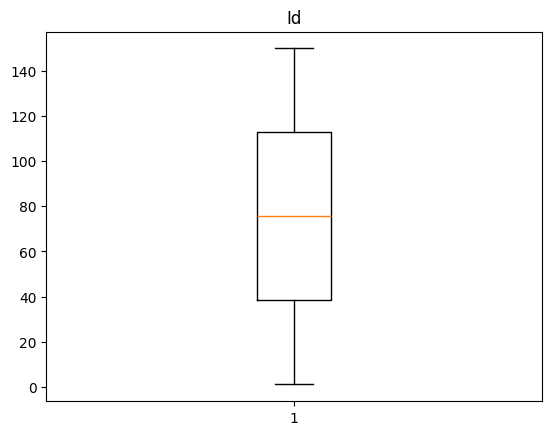

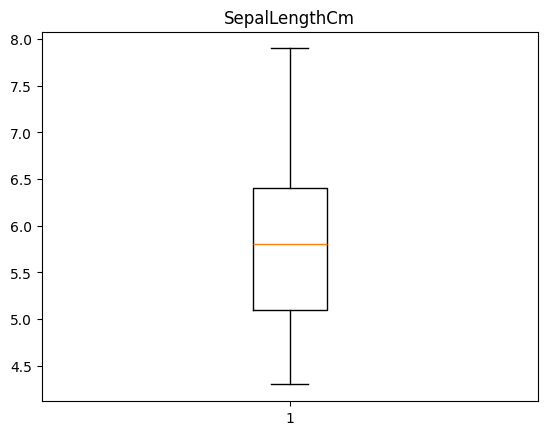

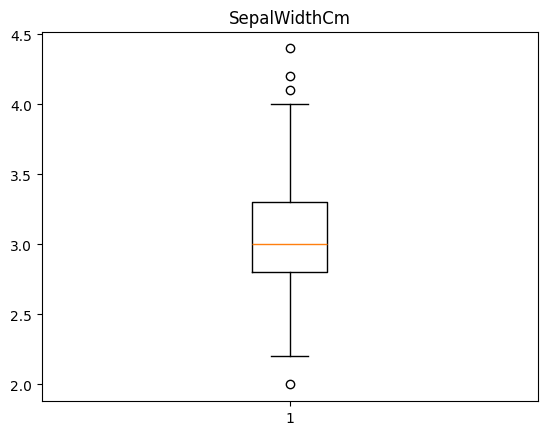

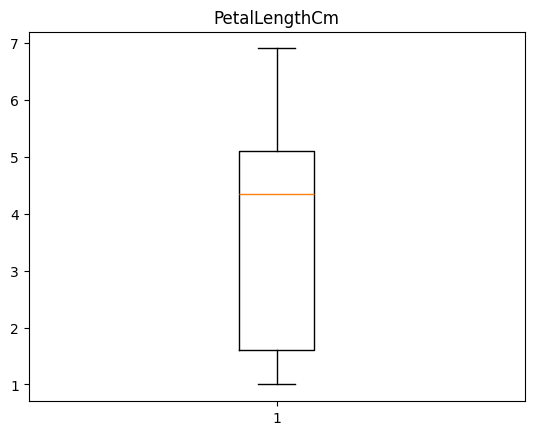

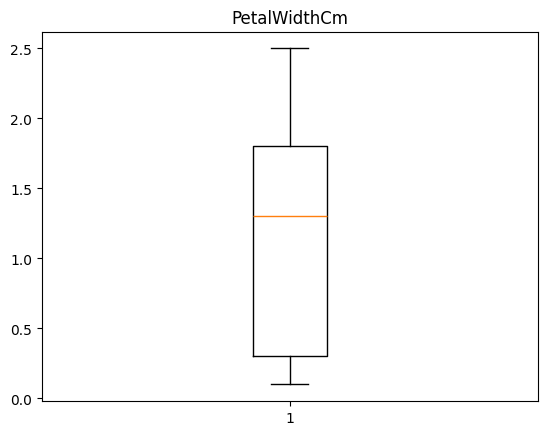


EDA completed


In [ ]:
from google.colab import files
uploaded = files.upload()

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('Iris.csv')

print(df.head())
print(df.info())
print(df.describe())

print("Missing values:")
print(df.isnull().sum())

df.fillna(df.mean(numeric_only=True), inplace=True)

for col in df.select_dtypes(include='number'):
    plt.boxplot(df[col])
    plt.title(col)
    plt.show()

print("\nEDA completed")

In [ ]:
import pandas as pd
from sklearn.feature_selection import chi2

df = pd.read_csv('Iris.csv')

print(df.head())
print(df.info())
print(df.describe())
x = df.iloc[:, 1:5].abs()
y = df['Species']
chi_scores, _ = chi2(x, y)
chi_series = pd.Series(chi_scores, index=x.columns)
print(chi_series)

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB
None
               

First 5 PCA reduced features:
 [[-2.26470281  0.4800266 ]
 [-2.08096115 -0.67413356]
 [-2.36422905 -0.34190802]
 [-2.29938422 -0.59739451]
 [-2.38984217  0.64683538]]

First 5 LDA reduced features:
 [[ 8.06179978 -0.30042062]
 [ 7.12868772  0.78666043]
 [ 7.48982797  0.26538449]
 [ 6.81320057  0.67063107]
 [ 8.13230933 -0.51446253]]

Classification Accuracy:
PCA Accuracy: 0.9555555555555556
LDA Accuracy: 1.0


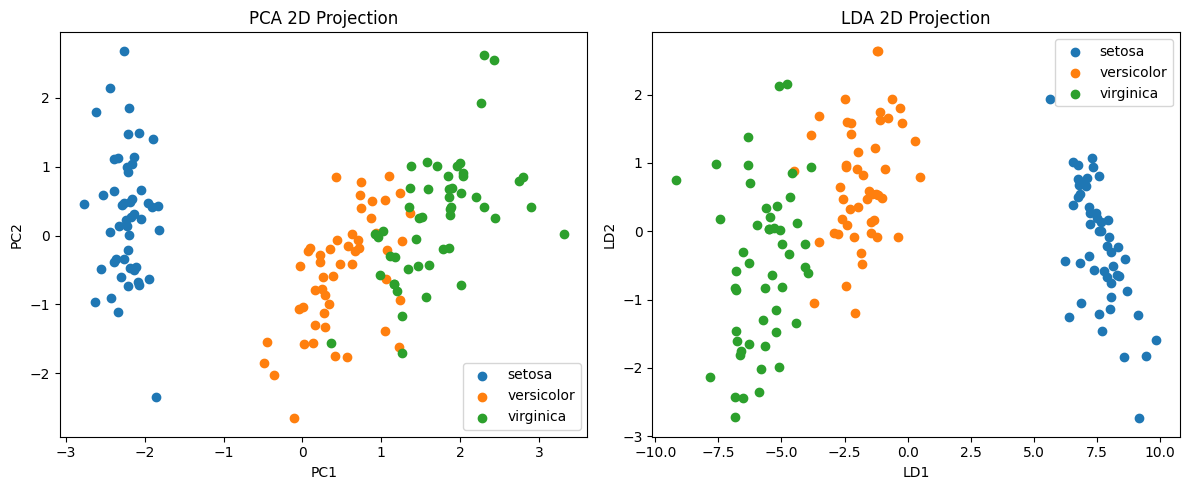

In [ ]:
# PCA vs LDA Comparison Example

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score


data = load_iris()
X = data.data
y = data.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("First 5 PCA reduced features:\n", X_pca[:5])


lda = LDA(n_components=2)
X_lda = lda.fit_transform(X_scaled, y)

print("\nFirst 5 LDA reduced features:\n", X_lda[:5])

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)

X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

X_train_lda = lda.fit_transform(X_train, y_train)
X_test_lda = lda.transform(X_test)


knn = KNeighborsClassifier(n_neighbors=3)

knn.fit(X_train_pca, y_train)
y_pred_pca = knn.predict(X_test_pca)
pca_acc = accuracy_score(y_test, y_pred_pca)

knn.fit(X_train_lda, y_train)
y_pred_lda = knn.predict(X_test_lda)
lda_acc = accuracy_score(y_test, y_pred_lda)

print("\nClassification Accuracy:")
print("PCA Accuracy:", pca_acc)
print("LDA Accuracy:", lda_acc)

plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
for label in np.unique(y):
    plt.scatter(X_pca[y == label, 0], X_pca[y == label, 1], label=data.target_names[label])
plt.title("PCA 2D Projection")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()

plt.subplot(1, 2, 2)
for label in np.unique(y):
    plt.scatter(X_lda[y == label, 0], X_lda[y == label, 1], label=data.target_names[label])
plt.title("LDA 2D Projection")
plt.xlabel("LD1")
plt.ylabel("LD2")
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
# Sequential Forward Selection vs Backward Elimination

import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.feature_selection import SequentialFeatureSelector


data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LogisticRegression(max_iter=5000)


sfs = SequentialFeatureSelector(
    model,
    n_features_to_select=5,
    direction='forward',
    scoring='accuracy',
    cv=5
)

sfs.fit(X_train, y_train)

sfs_features = feature_names[sfs.get_support()]
print("Top features using Forward Selection:")
print(sfs_features)

X_train_sfs = sfs.transform(X_train)
X_test_sfs = sfs.transform(X_test)

model.fit(X_train_sfs, y_train)
y_pred_sfs = model.predict(X_test_sfs)
sfs_acc = accuracy_score(y_test, y_pred_sfs)


sbe = SequentialFeatureSelector(
    model,
    n_features_to_select=5,
    direction='backward',
    scoring='accuracy',
    cv=5
)

sbe.fit(X_train, y_train)

sbe_features = feature_names[sbe.get_support()]
print("\nTop features using Backward Elimination:")
print(sbe_features)

X_train_sbe = sbe.transform(X_train)
X_test_sbe = sbe.transform(X_test)

model.fit(X_train_sbe, y_train)
y_pred_sbe = model.predict(X_test_sbe)
sbe_acc = accuracy_score(y_test, y_pred_sbe)


print("\nModel Performance Comparison:")
print("Forward Selection Accuracy:", sfs_acc)
print("Backward Elimination Accuracy:", sbe_acc)


Top features using Forward Selection:
['mean concave points' 'mean symmetry' 'worst texture' 'worst area'
 'worst symmetry']

Top features using Backward Elimination:
['worst radius' 'worst texture' 'worst smoothness' 'worst concavity'
 'worst symmetry']

Model Performance Comparison:
Forward Selection Accuracy: 0.965034965034965
Backward Elimination Accuracy: 0.972027972027972


      crim    zn  indus  chas    nox     rm   age     dis  rad  tax  ptratio  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        b  lstat  medv  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float6

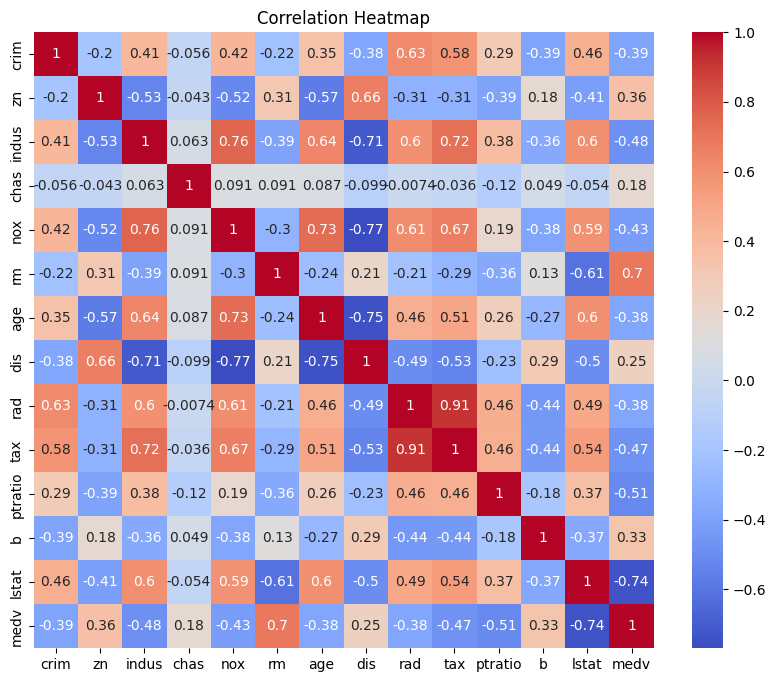

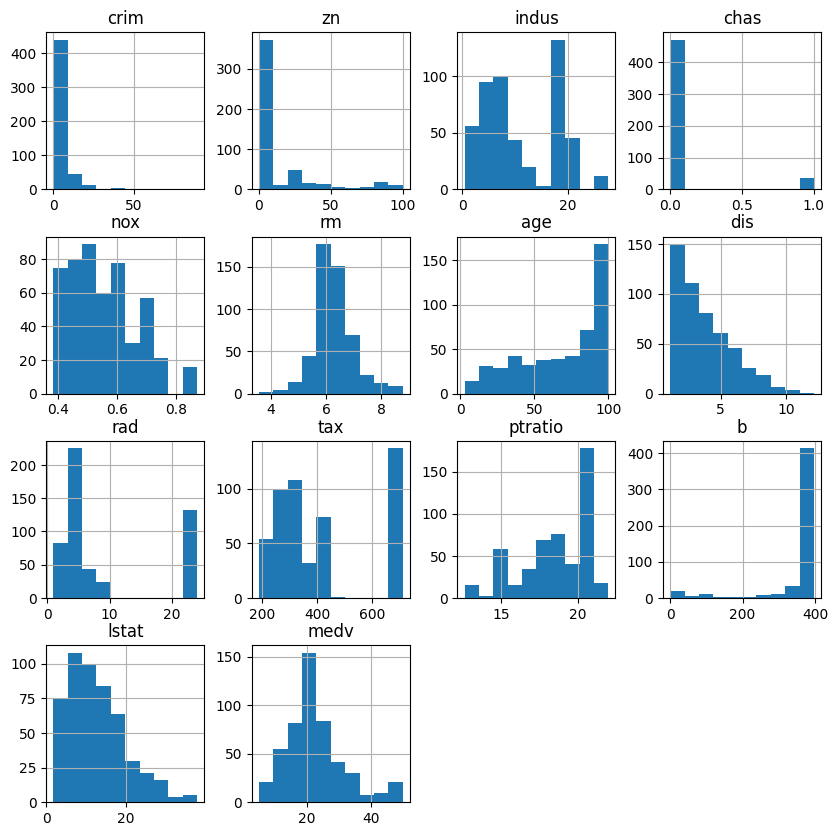

EDA Completed


In [ ]:
# EXP 5: EDA + Preprocessing

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Load dataset
df = pd.read_csv("https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv")
# Display data
print(df.head())
print(df.info())
print(df.describe())

# Check missing values
print("\nMissing Values:\n", df.isnull().sum())

# Fill missing values
df.fillna(df.mean(), inplace=True)

# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Distribution plot
df.hist(figsize=(10,10))
plt.show()

print("EDA Completed")

In [ ]:
# EXP 6: House Price Prediction (Regression)

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Load dataset (direct link - no upload needed)
url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"
df = pd.read_csv(url)

# Check data
print(df.head())

# Features & Target
X = df.drop('medv', axis=1)
y = df['medv']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Models
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(),
    "Gradient Boosting": GradientBoostingRegressor()
}

# Training & Evaluation
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results[name] = [mae, mse, r2]

# Show Results
results_df = pd.DataFrame(results, index=["MAE", "MSE", "R2 Score"]).T
print("\nModel Comparison:\n")
print(results_df)

# Best Model
best_model = results_df['R2 Score'].idxmax()
print("\nBest Model:", best_model)

      crim    zn  indus  chas    nox     rm   age     dis  rad  tax  ptratio  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        b  lstat  medv  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  

Model Comparison:

                        MAE        MSE  R2 Score
Linear Regression  3.189092  24.291119  0.668759
Decision Tree      2.233333   8.880784  0.878899
Random Forest      2.191716   9.224530  0.874212
Gradient Boosting  1.910109   6.193833  0.915539

Best Model: Gradient Boosting


   Unnamed: 0   Loan_ID  Gender Married Dependents     Education  \
0           0  LP002305  Female      No          0      Graduate   
1           1  LP001715    Male     Yes         3+  Not Graduate   
2           2  LP002086  Female     Yes          0      Graduate   
3           3  LP001136    Male     Yes          0  Not Graduate   
4           4  LP002529    Male     Yes          2      Graduate   

  Self_Employed  ApplicantIncome  CoapplicantIncome  LoanAmount  \
0            No             4547                0.0       115.0   
1           Yes             5703                0.0       130.0   
2            No             4333             2451.0       110.0   
3           Yes             4695                0.0        96.0   
4            No             6700             1750.0       230.0   

   Loan_Amount_Term  Credit_History Property_Area  Loan_Status  
0             360.0             1.0     Semiurban            1  
1             360.0             1.0         Rural         

/tmp/ipykernel_5146/3668824185.py:20: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)



Best Parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Best Score: 0.7984420642648491


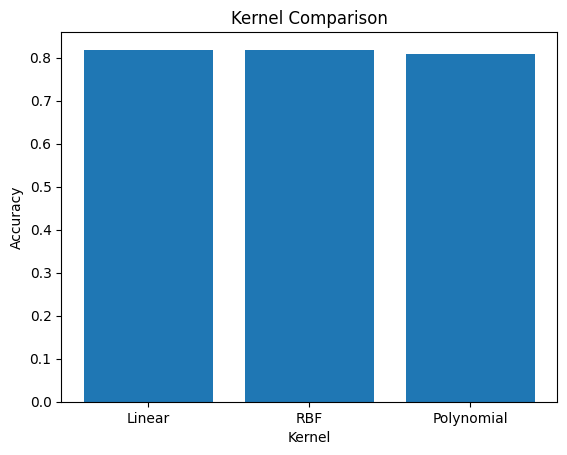

In [ ]:
# EXP 7: SVM Loan Approval Prediction

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Load dataset (direct link)
url = "https://raw.githubusercontent.com/dphi-official/Datasets/master/Loan_Data/loan_train.csv"
df = pd.read_csv(url)

# Show data
print(df.head())

# Handle missing values
df.fillna(method='ffill', inplace=True)

# Convert categorical to numeric
le = LabelEncoder()
for col in df.select_dtypes(include='object'):
    df[col] = le.fit_transform(df[col])

# Features & Target
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# SVM Models
models = {
    "Linear": SVC(kernel='linear', C=1),
    "RBF": SVC(kernel='rbf', C=1, gamma='scale'),
    "Polynomial": SVC(kernel='poly', degree=3, C=1)
}

# Train & Evaluate
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    print(f"\n{name} Kernel")
    print("Accuracy:", acc)
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))

# Hyperparameter Tuning
param_grid = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 0.1],
    'kernel': ['rbf']
}

grid = GridSearchCV(SVC(), param_grid, cv=5)
grid.fit(X_train, y_train)

print("\nBest Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)

# Plot Kernel Accuracy
plt.bar(results.keys(), results.values())
plt.title("Kernel Comparison")
plt.xlabel("Kernel")
plt.ylabel("Accuracy")
plt.show()

Saving bank-full.csv to bank-full (3).csv
   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married    unknown      no     1506     yes   no   
4   33       unknown   single    unknown      no        1      no   no   

   contact  day month  duration  campaign  pdays  previous poutcome   y  
0  unknown    5   may       261         1     -1         0  unknown  no  
1  unknown    5   may       151         1     -1         0  unknown  no  
2  unknown    5   may        76         1     -1         0  unknown  no  
3  unknown    5   may        92         1     -1         0  unknown  no  
4  unknown    5   may       198         1     -1         0  unknown  no  
   age           job  marital  education default  balance housing loa

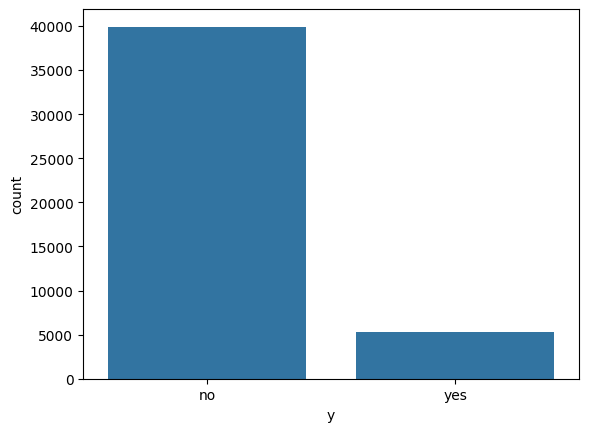

   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married    unknown      no     1506     yes   no   
4   33       unknown   single    unknown      no        1      no   no   

   contact  day month  duration  campaign  pdays  previous poutcome   y  
0  unknown    5   may       261         1     -1         0  unknown  no  
1  unknown    5   may       151         1     -1         0  unknown  no  
2  unknown    5   may        76         1     -1         0  unknown  no  
3  unknown    5   may        92         1     -1         0  unknown  no  
4  unknown    5   may       198         1     -1         0  unknown  no  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #

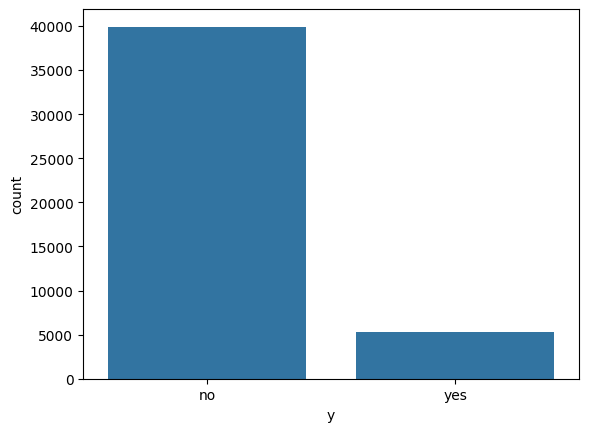

Accuracy: 0.9019130819418335
Confusion Matrix:
 [[7702  250]
 [ 637  454]]
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.97      0.95      7952
           1       0.64      0.42      0.51      1091

    accuracy                           0.90      9043
   macro avg       0.78      0.69      0.73      9043
weighted avg       0.89      0.90      0.89      9043

Accuracy: 0.9013601680858122
Confusion Matrix:
 [[7700  252]
 [ 640  451]]
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.97      0.95      7952
           1       0.64      0.41      0.50      1091

    accuracy                           0.90      9043
   macro avg       0.78      0.69      0.72      9043
weighted avg       0.89      0.90      0.89      9043



In [ ]:
# EXP 8: Bank Marketing (NO ERROR FINAL)

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Direct dataset (NO ZIP)
from google.colab import files
files.upload()

# ✅ Correct line
df = pd.read_csv('bank-full (1).csv', sep=';')

print(df.head())

# Show data
print(df.head())
print(df.info())

# EDA
sns.countplot(x='y', data=df)
plt.show()

# Convert categorical to numeric
le = LabelEncoder()
for col in df.select_dtypes(include='object'):
    df[col] = le.fit_transform(df[col])

# Features & Target
X = df.drop('y', axis=1)
y = df['y']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Model
model = RandomForestClassifier# EXP 8: Bank Marketing (FINAL - LOCAL FILE)

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load uploaded file
df = pd.read_csv('bank-full.csv', sep=';')

# Show data
print(df.head())
print(df.info())

# EDA
sns.countplot(x='y', data=df)
plt.show()

# Convert categorical to numeric
le = LabelEncoder()
for col in df.select_dtypes(include='object'):
    df[col] = le.fit_transform(df[col])

# Features & Target
X = df.drop('y', axis=1)
y = df['y']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Model
model = RandomForestClassifier()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Results
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Results
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

In [ ]:
# EXP 9: Decision Tree Performance

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Sample Play Tennis Dataset
data = {
    'Outlook': ['Sunny','Sunny','Overcast','Rain','Rain','Rain','Overcast','Sunny','Sunny','Rain','Sunny','Overcast','Overcast','Rain'],
    'Temp': ['Hot','Hot','Hot','Mild','Cool','Cool','Mild','Hot','Cool','Mild','Mild','Mild','Hot','Mild'],
    'Humidity': ['High','High','High','High','Normal','Normal','Normal','High','Normal','Normal','Normal','High','Normal','High'],
    'Wind': ['Weak','Strong','Weak','Weak','Weak','Strong','Strong','Weak','Weak','Weak','Strong','Strong','Weak','Strong'],
    'Play': ['No','No','Yes','Yes','Yes','No','Yes','No','Yes','Yes','Yes','Yes','Yes','No']
}

df = pd.DataFrame(data)

# Encode categorical data
le = LabelEncoder()
for col in df.columns:
    df[col] = le.fit_transform(df[col])

# Features & Target
X = df.drop('Play', axis=1)
y = df['Play']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Model
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 1.0
Confusion Matrix:
 [[1 0]
 [0 2]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         2

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



In [ ]:
!pip install mlxtend

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Online Retail.xlsx to Online Retail (1).xlsx


In [ ]:
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules

df = pd.read_excel('Online Retail.xlsx')
df = df.head(20000)
df = df.dropna()
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
df = df[['InvoiceNo', 'Description', 'Quantity']]
df = df[df['Quantity'] > 0]

basket = df.groupby(['InvoiceNo', 'Description'])['Quantity'].sum().unstack().fillna(0)
basket = (basket > 0)

frequent_itemsets = apriori(basket, min_support=0.05, use_colnames=True)
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)
rules = rules.sort_values(by='lift', ascending=False)

print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))


                       antecedents                      consequents   support  \
0  (HAND WARMER SCOTTY DOG DESIGN)         (HAND WARMER OWL DESIGN)  0.056577   
1         (HAND WARMER OWL DESIGN)  (HAND WARMER SCOTTY DOG DESIGN)  0.056577   

   confidence      lift  
0    0.597015  6.699834  
1    0.634921  6.699834  


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving customer_purchase_dataset.csv to customer_purchase_dataset.csv


In [ ]:
# ==============================
# ENSEMBLE LEARNING EXPERIMENT
# ==============================

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

df = pd.read_csv("customer_purchase_dataset.csv")

print("Dataset Preview:")
print(df.head())


le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])


X = df.iloc[:, :-1]
y = df.iloc[:, -1]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,
    random_state=42
)

bagging.fit(X_train, y_train)
y_pred_bag = bagging.predict(X_test)

print("\nBagging Accuracy:", accuracy_score(y_test, y_pred_bag))


adaboost = AdaBoostClassifier(
    n_estimators=100,
    random_state=42
)

adaboost.fit(X_train, y_train)
y_pred_ada = adaboost.predict(X_test)

print("AdaBoost Accuracy:", accuracy_score(y_test, y_pred_ada))


estimators = [
    ('dt', DecisionTreeClassifier()),
    ('svm', SVC(probability=True)),
    ('lr', LogisticRegression(max_iter=1000))
]

stacking = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(max_iter=1000)
)

stacking.fit(X_train, y_train)
y_pred_stack = stacking.predict(X_test)

print("Stacking Accuracy:", accuracy_score(y_test, y_pred_stack))


print("\n=== Model Comparison ===")
print("Bagging  :", accuracy_score(y_test, y_pred_bag))
print("AdaBoost :", accuracy_score(y_test, y_pred_ada))
print("Stacking :", accuracy_score(y_test, y_pred_stack))

Dataset Preview:
   Age  Income  Browsing_Time  Pages_Viewed  Purchase
0   22   25000              5             3         0
1   25   30000             10             5         0
2   28   35000             15             7         1
3   30   40000             20            10         1
4   35   50000             25            12         1

Bagging Accuracy: 1.0
AdaBoost Accuracy: 1.0
Stacking Accuracy: 1.0

=== Model Comparison ===
Bagging  : 1.0
AdaBoost : 1.0
Stacking : 1.0
